In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
insurance_dataset=pd.read_csv("data/insurance.csv")
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [22]:
insurance_dataset.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [23]:
print(insurance_dataset.isna().sum().sum())
print(insurance_dataset.duplicated().sum())

0
1


In [24]:
insurance_dataset=insurance_dataset.drop_duplicates()
print(insurance_dataset.duplicated().sum())

0


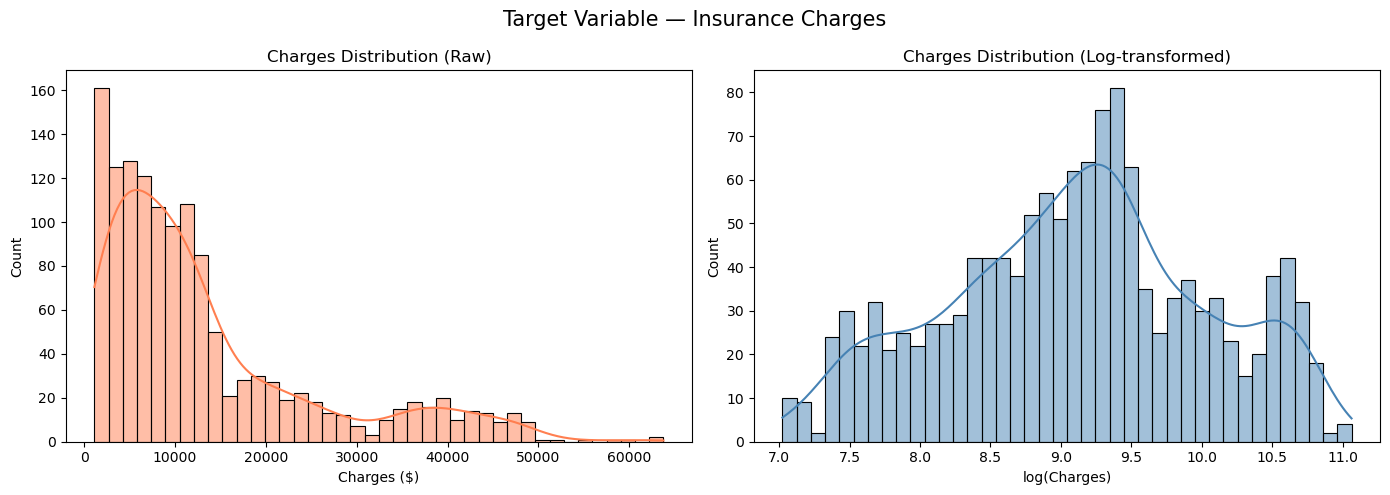

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(insurance_dataset["charges"], kde=True, bins=40, color="coral", ax=axes[0])
axes[0].set_title("Charges Distribution (Raw)")
axes[0].set_xlabel("Charges ($)")

# Log-transformed (important — charges are right-skewed)
sns.histplot(np.log1p(insurance_dataset["charges"]), kde=True, bins=40, color="steelblue", ax=axes[1])
axes[1].set_title("Charges Distribution (Log-transformed)")
axes[1].set_xlabel("log(Charges)")

plt.suptitle("Target Variable — Insurance Charges", fontsize=15)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14348\4177209197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=insurance_dataset, x=col, y="charges", palette="Set2", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_14348\4177209197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=insurance_dataset, x=col, y="charges", palette="Set2", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_14348\4177209197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=insurance_dataset, x=col, y="charges", palette="Set2", ax=axes[i])


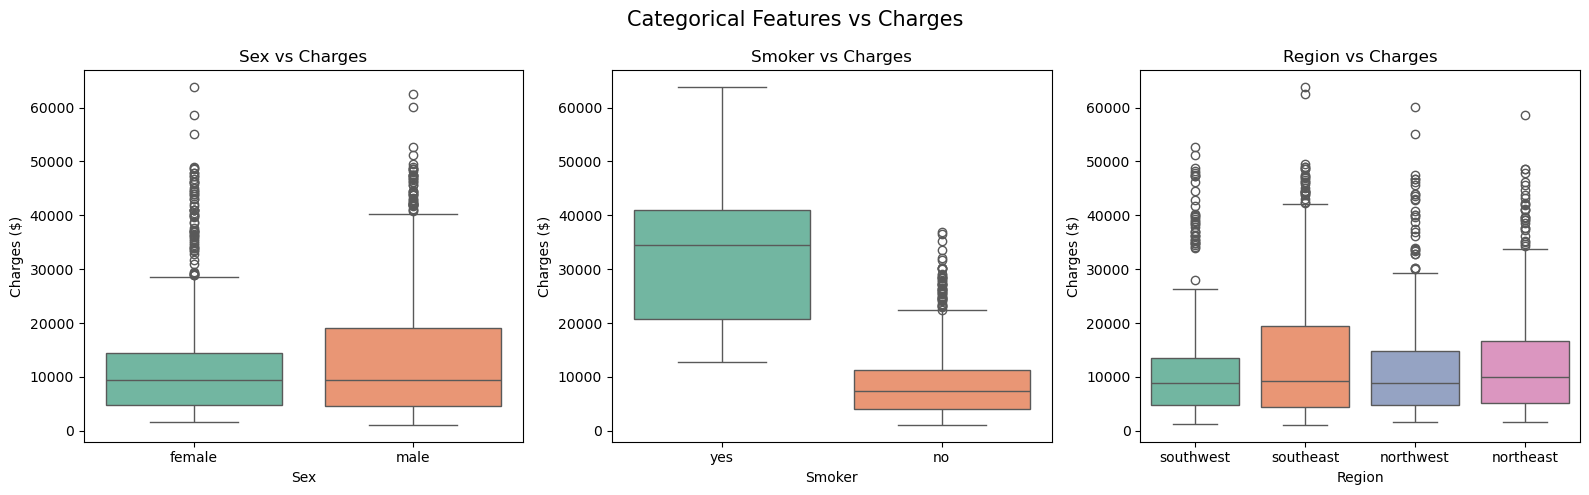

In [26]:
cat_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(data=insurance_dataset, x=col, y="charges", palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col.capitalize()} vs Charges")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Charges ($)")

plt.suptitle("Categorical Features vs Charges", fontsize=15)
plt.tight_layout()
plt.show()

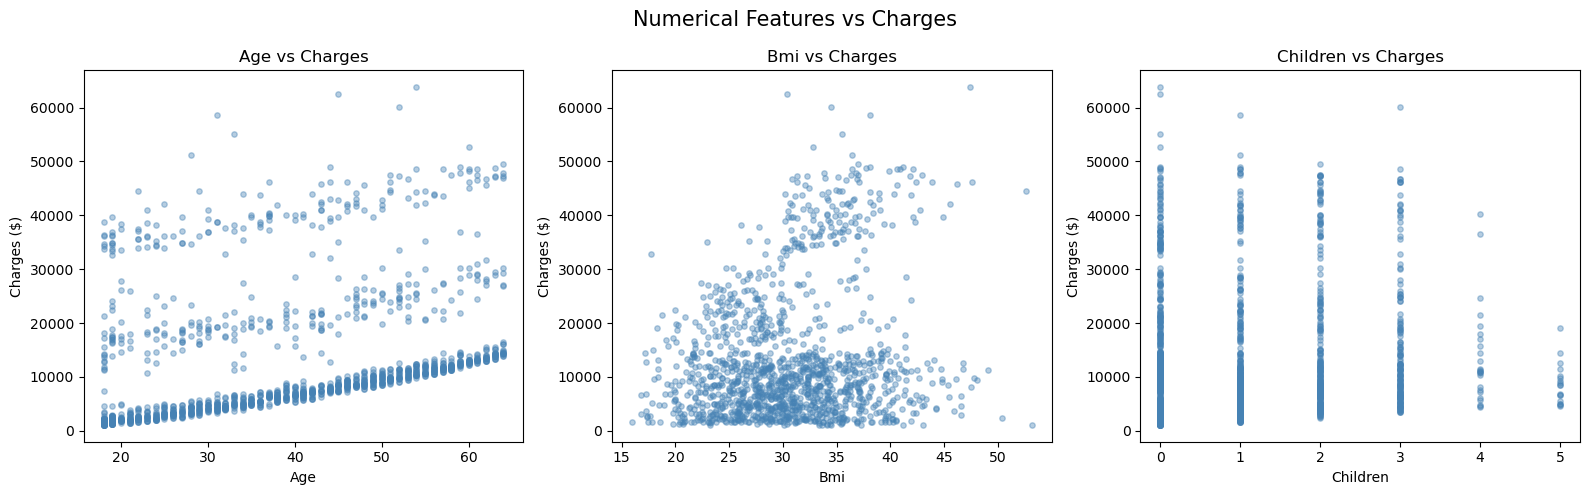

In [27]:
num_cols = ["age", "bmi", "children"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    axes[i].scatter(insurance_dataset[col], insurance_dataset["charges"], alpha=0.4, color="steelblue", s=15)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Charges ($)")
    axes[i].set_title(f"{col.capitalize()} vs Charges")

plt.suptitle("Numerical Features vs Charges", fontsize=15)
plt.tight_layout()
plt.show()

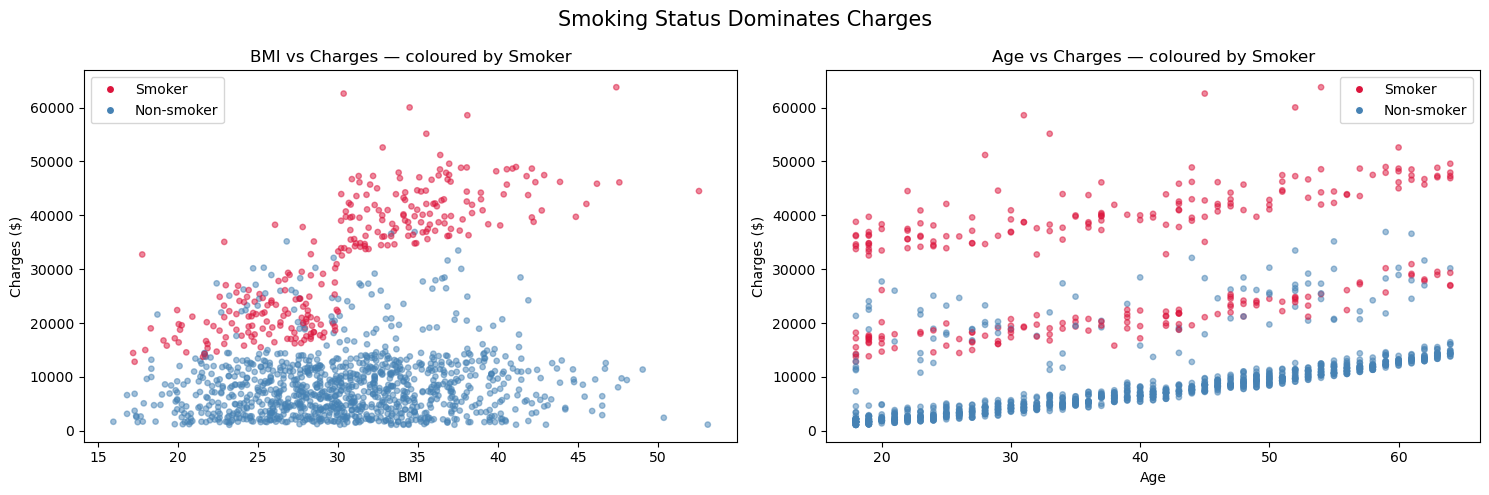

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# BMI vs Charges coloured by smoker
colors = insurance_dataset["smoker"].map({"yes": "crimson", "no": "steelblue"})
axes[0].scatter(insurance_dataset["bmi"], insurance_dataset["charges"], c=colors, alpha=0.5, s=15)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Charges ($)")
axes[0].set_title("BMI vs Charges — coloured by Smoker")
axes[0].legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', label='Smoker'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Non-smoker')
])

# Age vs Charges coloured by smoker
axes[1].scatter(insurance_dataset["age"], insurance_dataset["charges"], c=colors, alpha=0.5, s=15)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Charges ($)")
axes[1].set_title("Age vs Charges — coloured by Smoker")
axes[1].legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', label='Smoker'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Non-smoker')
])

plt.suptitle("Smoking Status Dominates Charges", fontsize=15)
plt.tight_layout()
plt.show()

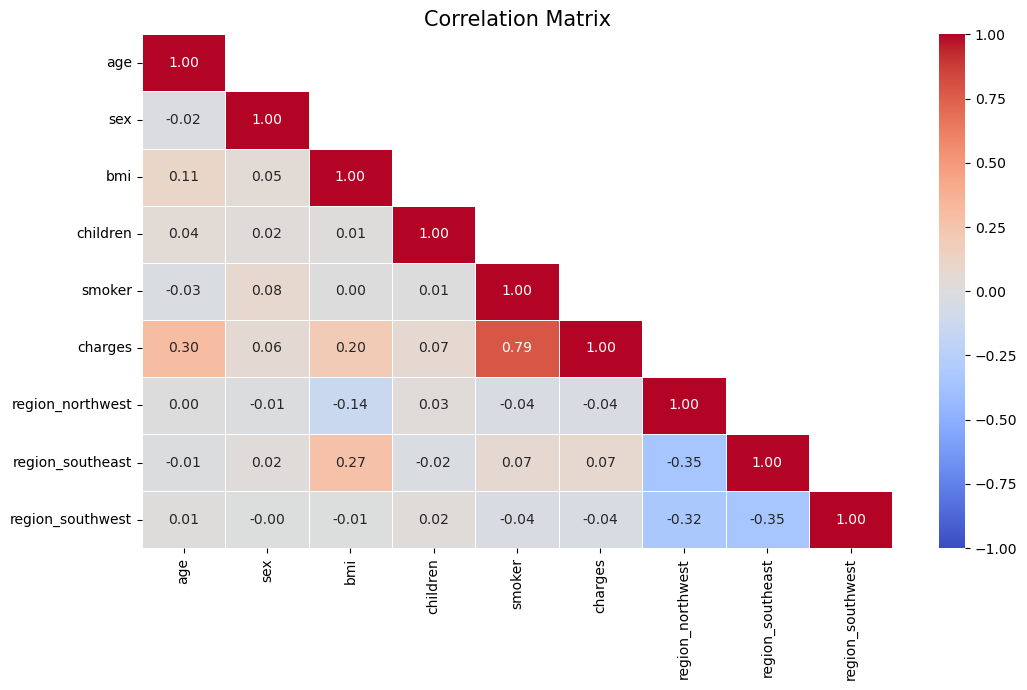

In [29]:
df_encoded = insurance_dataset.copy()
df_encoded["smoker"]  = df_encoded["smoker"].map({"yes": 1, "no": 0})
df_encoded["sex"]     = df_encoded["sex"].map({"male": 1, "female": 0})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

plt.figure(figsize=(11, 7))
mask = np.triu(np.ones(df_encoded.corr().shape), k=1).astype(bool)
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontsize=15)
plt.tight_layout()
plt.show()

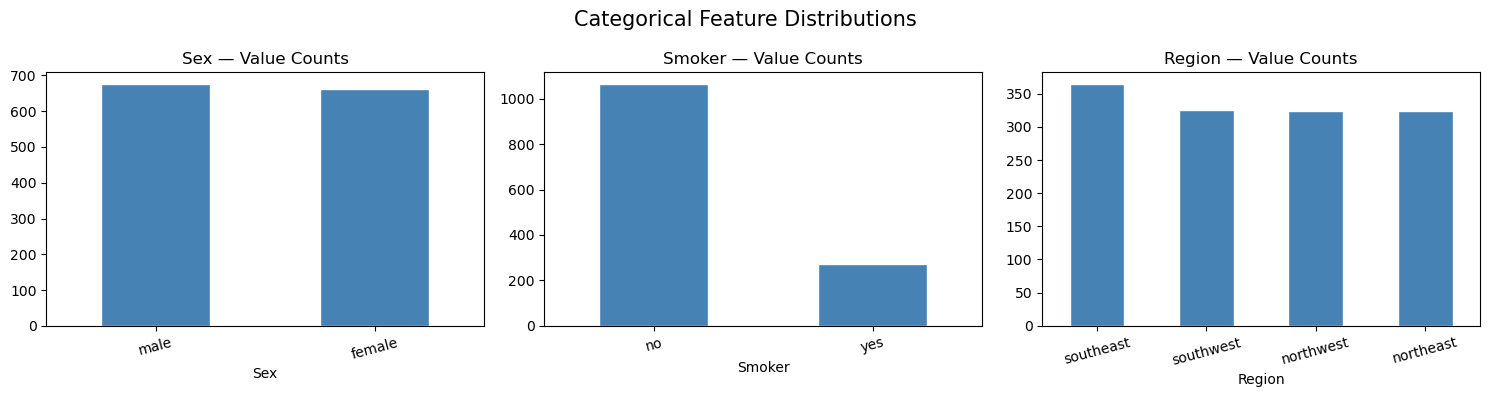

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_cols):
    insurance_dataset[col].value_counts().plot(kind="bar", ax=axes[i],
                                 color="steelblue", edgecolor="white")
    axes[i].set_title(f"{col.capitalize()} — Value Counts")
    axes[i].set_xlabel(col.capitalize())
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("Categorical Feature Distributions", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
insurance_dataset["smoker"] = insurance_dataset["smoker"].map({"yes": 1, "no": 0})
insurance_dataset["sex"]    = insurance_dataset["sex"].map({"male": 1, "female": 0})
insurance_dataset = pd.get_dummies(insurance_dataset, columns=["region"], drop_first=True)

insurance_dataset["bmi_smoker"]    = insurance_dataset["bmi"] * insurance_dataset["smoker"]      
insurance_dataset["age_smoker"]    = insurance_dataset["age"] * insurance_dataset["smoker"]
insurance_dataset["age2"]          = insurance_dataset["age"] ** 2               
insurance_dataset["bmi2"]          = insurance_dataset["bmi"] ** 2
insurance_dataset["obese"]         = (insurance_dataset["bmi"] >= 30).astype(int)
insurance_dataset["obese_smoker"]  = insurance_dataset["obese"] * insurance_dataset["smoker"] 

insurance_dataset["log_charges"] = np.log1p(insurance_dataset["charges"])

target = "log_charges"
X = insurance_dataset.drop(columns=["charges", "log_charges"])
y = insurance_dataset[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Features: {X.columns.tolist()}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'age_smoker', 'age2', 'bmi2', 'obese', 'obese_smoker']
Train: (1069, 14) | Test: (268, 14)


In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

def evaluate(name, y_true, y_pred_log):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    r2   = r2_score(y_true_orig, y_pred_orig)
    print(f"{name:30s} | RMSE: ${rmse:>8.2f} | MAE: ${mae:>7.2f} | R²: {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

models = {
    "Linear Regression":     (LinearRegression(),True),
    "Ridge":                 (Ridge(alpha=1.0),True),
    "Lasso":                 (Lasso(alpha=0.001),True),
    "Random Forest":         (RandomForestRegressor(n_estimators=100,random_state=42),False),
    "Gradient Boosting":     (GradientBoostingRegressor(n_estimators=200,random_state=42),False),
    "XGBoost":               (xgb.XGBRegressor(n_estimators=200,learning_rate=0.05, random_state=42,verbosity=0),False),
}

results  = []
trained  = {}

print(f"{'Model':30s} | {'RMSE':>12} | {'MAE':>10} | {'R²':>7}")
print("-" * 70)

for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    results.append(evaluate(name, y_test, preds))
    trained[name] = (model, preds, use_scaled)

Model                          |         RMSE |        MAE |      R²
----------------------------------------------------------------------
Linear Regression              | RMSE: $ 4812.78 | MAE: $2578.89 | R²: 0.8739
Ridge                          | RMSE: $ 4776.84 | MAE: $2543.27 | R²: 0.8758
Lasso                          | RMSE: $ 4715.92 | MAE: $2490.30 | R²: 0.8790
Random Forest                  | RMSE: $ 4415.70 | MAE: $2104.38 | R²: 0.8939
Gradient Boosting              | RMSE: $ 5249.97 | MAE: $2542.25 | R²: 0.8500
XGBoost                        | RMSE: $ 4534.11 | MAE: $2171.40 | R²: 0.8881


<Figure size 640x480 with 0 Axes>

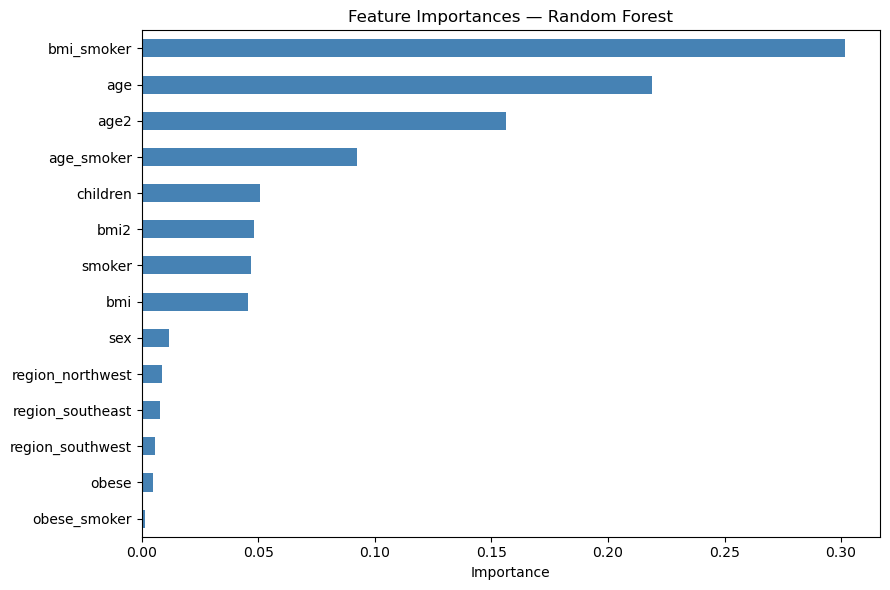

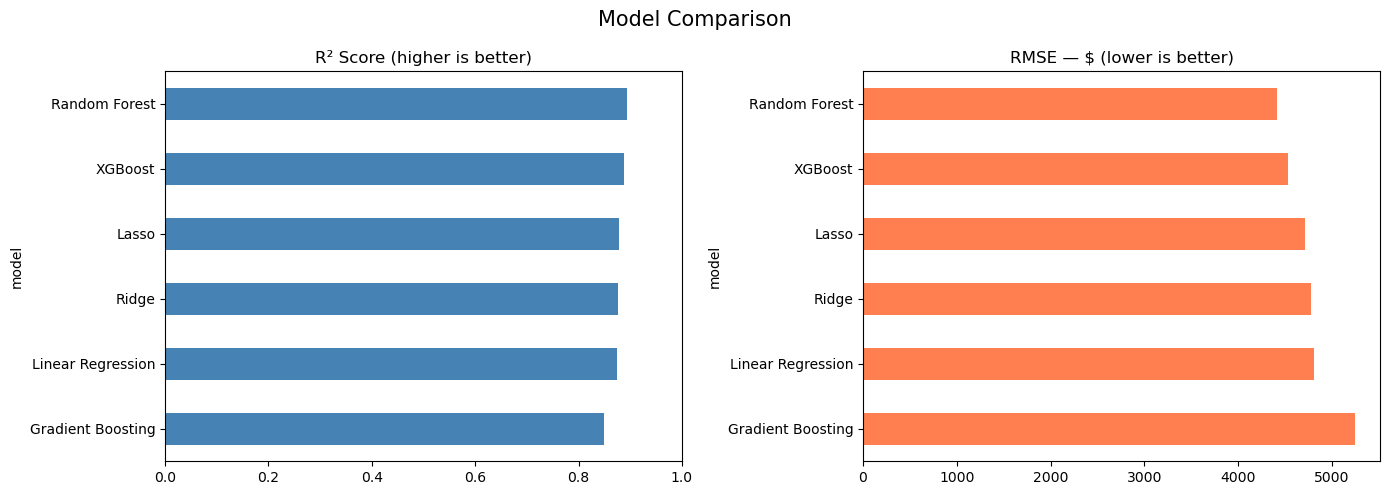

In [35]:
import matplotlib.pyplot as plt

# ── Actual vs Predicted — best model ──────────────────────
best_name = "Random Forest"
_, best_preds_log, _ = trained[best_name]

y_true_orig = np.expm1(y_test)
y_pred_orig = np.expm1(best_preds_log)

plt.suptitle("Model Performance", fontsize=15)
plt.tight_layout()
plt.show()

# ── Feature Importance ─────────────────────────────────────
xgb_model = trained["Random Forest"][0]
importances = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ── Model comparison ───────────────────────────────────────
results_df = pd.DataFrame(results).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df["R2"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("R² Score (higher is better)")
axes[0].set_xlim(0, 1)

results_df["RMSE"].sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="coral")
axes[1].set_title("RMSE — $ (lower is better)")

plt.suptitle("Model Comparison", fontsize=15)
plt.tight_layout()
plt.show()